# PHASE 10: FINAL RESEARCH SYNTHESIS AND COMPREHENSIVE ANALYSIS

Phase 10 là phase tổng hợp cuối cùng của dự án PlantVillage Disease Classification. Phase này **không train thêm model lớn**, mà tổng hợp kết quả từ các phase trước để xây dựng scientific narrative hoàn chỉnh ở mức paper/thesis quality.

Trọng tâm:

- cross-phase comparison,
- statistical/fairness analysis,
- efficiency and explainability synthesis,
- limitations and future work,
- final reports and publication-ready figures.


# 01. Thiết lập môi trường và thư mục output

Notebook này đọc artifacts từ Phase 05-09. Nếu phase nào chưa chạy xong hoặc thiếu CSV, notebook sẽ ghi nhận vào `missing_artifacts` thay vì dừng toàn bộ analysis.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    from IPython.display import display
except ImportError:
    display = print

def bootstrap_project_dir() -> Path:
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        candidates = [root, root / 'plan']
        for candidate in candidates:
            if (candidate / 'src').exists():
                if str(candidate) not in sys.path:
                    sys.path.append(str(candidate))
                from src.paths import find_project_dir
                return find_project_dir(candidate)
    raise FileNotFoundError('Không tìm thấy thư mục project plan chứa src/. Hãy chạy notebook từ repo hoặc thư mục plan.')


PROJECT_DIR = bootstrap_project_dir()

from src.data import ProjectPaths, ensure_directories
from src.utils import dataframe_to_markdown_safe, write_text_report
from src.visualization import set_publication_style, annotate_bars

set_publication_style()

PATHS = ProjectPaths(PROJECT_DIR)
RESULTS_ROOT = PROJECT_DIR / 'results'
RESULTS_DIR = PATHS.results_dir('10_final_research_synthesis')
REPORTS_DIR = PATHS.reports_dir('10_final_research_synthesis')
PHASE10_DIR = RESULTS_DIR / 'phase_10_final_research_synthesis'
PHASE10_FIGURE_DIR = PHASE10_DIR / 'figures'
PHASE10_TABLE_DIR = PHASE10_DIR / 'tables'
PHASE10_REPORT_DIR = PHASE10_DIR / 'reports'

ensure_directories(
    RESULTS_DIR,
    REPORTS_DIR,
    PHASE10_DIR,
    PHASE10_FIGURE_DIR,
    PHASE10_TABLE_DIR,
    PHASE10_REPORT_DIR,
)

missing_artifacts = []
print(f'Output directory: {PHASE10_DIR}')



Output directory: /Users/huynh/codes/kpdl/plan/results/10_final_research_synthesis/phase_10_final_research_synthesis


# 02. Helper functions để load và chuẩn hóa kết quả

Các phase có tên cột hơi khác nhau (`Worst-class Recall`, `Worst Recall`, `Macro F1`). Cell này chuẩn hóa format để tạo bảng cuối.


In [2]:
def read_csv_if_exists(path, description):
    if path.exists():
        return pd.read_csv(path)
    missing_artifacts.append({'Artifact': description, 'Path': str(path)})
    return None


def normalize_metric_columns(df):
    if df is None or df.empty:
        return pd.DataFrame()
    df = df.copy()
    if 'Worst-class Recall' in df.columns and 'Worst Recall' not in df.columns:
        df = df.rename(columns={'Worst-class Recall': 'Worst Recall'})
    if 'Model' in df.columns and 'Experiment' not in df.columns:
        df = df.rename(columns={'Model': 'Experiment'})
    return df


def add_record(records, phase, model, strategy, row, source):
    if row is None or len(row) == 0:
        return
    row = row.iloc[0] if isinstance(row, pd.DataFrame) else row
    records.append({
        'Phase': phase,
        'Model': model,
        'Strategy': strategy,
        'Experiment': row.get('Experiment', model),
        'Accuracy': row.get('Accuracy', np.nan),
        'Macro Precision': row.get('Macro Precision', np.nan),
        'Macro Recall': row.get('Macro Recall', np.nan),
        'Macro F1': row.get('Macro F1', np.nan),
        'Minority Recall': row.get('Minority Recall', np.nan),
        'Worst Recall': row.get('Worst Recall', row.get('Worst-class Recall', np.nan)),
        'Params': row.get('Params', np.nan),
        'Inference Time ms/image': row.get('Inference Time ms/image', np.nan),
        'Source': source,
    })


def compute_summary_from_predictions(prediction_path, per_class_path, experiment_name):
    pred_df = pd.read_csv(prediction_path)
    y_true = pred_df['true_label'].values
    y_pred = pred_df['predicted_label'].values
    accuracy = accuracy_score(y_true, y_pred)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='macro',
        zero_division=0,
    )

    per_class_df = pd.read_csv(per_class_path)
    minority_df = per_class_df[per_class_df.get('Is Minority', False) == True]
    minority_recall = minority_df['Recall'].mean() if not minority_df.empty else np.nan
    worst_recall = per_class_df['Recall'].min() if 'Recall' in per_class_df.columns else np.nan

    return {
        'Experiment': experiment_name,
        'Accuracy': accuracy,
        'Macro Precision': macro_precision,
        'Macro Recall': macro_recall,
        'Macro F1': macro_f1,
        'Minority Recall': minority_recall,
        'Worst Recall': worst_recall,
    }


def get_best_row(df, metric='Macro F1'):
    if df is None or df.empty or metric not in df.columns:
        return None
    return df.sort_values(metric, ascending=False).iloc[0]



# 03. Load results từ Phase 05-09

Phase 10 tổng hợp các kết quả chính:

- SimpleCNN baseline,
- Phase 05 winner,
- Phase 06 best loss,
- Phase 07 SimpleCNN hybrid strategy,
- Phase 08 MobileNetV2 winner,
- Phase 08 EfficientNet-B0 winner,
- Improved MobileNetV2 final model.


In [3]:
phase05_path = RESULTS_ROOT / '05_imbalance_analysis' / 'phase_05_analysis' / 'tables' / 'ablation_study_summary.csv'
phase06_path = RESULTS_ROOT / '06_loss_function_study' / 'phase_06_loss_study' / 'tables' / 'loss_function_comparison.csv'
phase07_path = RESULTS_ROOT / '07_simplecnn_hybrid_strategy_study' / 'phase_07_simplecnn_hybrid_strategy' / 'tables' / 'phase07_hybrid_strategy_comparison.csv'
phase08_path = RESULTS_ROOT / '08_modern_pretrained_model_study' / 'phase_08_modern_pretrained_models' / 'tables' / 'phase08_modern_model_comparison.csv'
phase09_path = RESULTS_ROOT / '09_improved_mobilenetv2_architecture_study' / 'phase_09_improved_mobilenetv2' / 'tables' / 'improved_mobilenetv2_ablation_results.csv'
phase09_complexity_path = RESULTS_ROOT / '09_improved_mobilenetv2_architecture_study' / 'phase_09_improved_mobilenetv2' / 'tables' / 'improved_mobilenetv2_complexity.csv'

phase05_df = normalize_metric_columns(read_csv_if_exists(phase05_path, 'Phase 05 ablation summary'))
phase06_df = normalize_metric_columns(read_csv_if_exists(phase06_path, 'Phase 06 loss function comparison'))
phase07_df = normalize_metric_columns(read_csv_if_exists(phase07_path, 'Phase 07 SimpleCNN hybrid strategy summary'))
phase08_df = normalize_metric_columns(read_csv_if_exists(phase08_path, 'Phase 08 modern pretrained model comparison'))
phase09_df = normalize_metric_columns(read_csv_if_exists(phase09_path, 'Phase 09 improved MobileNetV2 ablation'))
phase09_complexity_df = read_csv_if_exists(phase09_complexity_path, 'Phase 09 complexity analysis')

# Phase 09 fallback: reconstruct summary from predictions/per-class metrics when ablation table has not been exported yet.
if phase09_df.empty:
    phase09_table_dir = RESULTS_ROOT / '09_improved_mobilenetv2_architecture_study' / 'phase_09_improved_mobilenetv2' / 'tables'
    reconstructed_records = []
    for pred_path in sorted(phase09_table_dir.glob('*_predictions.csv')):
        experiment_name = pred_path.name.replace('_predictions.csv', '')
        per_class_path = phase09_table_dir / f'{experiment_name}_per_class_metrics.csv'
        if per_class_path.exists():
            reconstructed_records.append(compute_summary_from_predictions(pred_path, per_class_path, experiment_name))
    phase09_df = normalize_metric_columns(pd.DataFrame(reconstructed_records))
    if not phase09_df.empty:
        phase09_df.to_csv(PHASE10_TABLE_DIR / 'phase09_reconstructed_summary.csv', index=False)

print('Phase 05 rows:', len(phase05_df))
print('Phase 06 rows:', len(phase06_df))
print('Phase 07 rows:', len(phase07_df))
print('Phase 08 rows:', len(phase08_df))
print('Phase 09 rows:', len(phase09_df))

if missing_artifacts:
    display(pd.DataFrame(missing_artifacts))


Phase 05 rows: 5
Phase 06 rows: 4
Phase 07 rows: 3
Phase 08 rows: 2
Phase 09 rows: 3


# 04. Final cross-phase comparison table

Bảng này là bảng chính của toàn project.


In [4]:
records = []

if not phase05_df.empty:
    add_record(records, 'Phase 05', 'SimpleCNN baseline', 'CrossEntropy baseline', phase05_df[phase05_df['Experiment'] == 'baseline'], 'Phase 05')
    add_record(records, 'Phase 05', 'Phase 05 winner', 'WeightedRandomSampler + Light Augmentation + EarlyStopping', phase05_df[phase05_df['Experiment'] == 'sampler_aug_earlystop'], 'Phase 05')

if not phase06_df.empty:
    phase06_best = get_best_row(phase06_df, metric='Macro F1')
    add_record(records, 'Phase 06', 'Best loss-level SimpleCNN', 'Best loss function strategy on SimpleCNN', phase06_best, 'Phase 06')

if not phase07_df.empty:
    phase07_best = get_best_row(phase07_df, metric='Macro F1')
    add_record(records, 'Phase 07', 'SimpleCNN hybrid strategy', 'Best Phase 05 strategy + best Phase 06 loss', phase07_best, 'Phase 07')

if not phase08_df.empty:
    add_record(records, 'Phase 08', 'MobileNetV2 winner', 'MobileNetV2 pretrained + sampler winner strategy', phase08_df[phase08_df['Experiment'] == 'mobilenetv2_winner'], 'Phase 08')
    add_record(records, 'Phase 08', 'EfficientNet-B0 winner', 'EfficientNet-B0 pretrained + sampler winner strategy', phase08_df[phase08_df['Experiment'] == 'efficientnet_b0_winner'], 'Phase 08')

if not phase09_df.empty:
    phase09_best = get_best_row(phase09_df, metric='Macro F1')
    add_record(records, 'Phase 09', 'Improved MobileNetV2 final model', 'Residual/attention enhanced MobileNetV2', phase09_best, 'Phase 09')

final_comparison_df = pd.DataFrame(records)
if final_comparison_df.empty:
    raise ValueError('No phase result artifacts were found. Run at least one experiment phase before Phase 10 synthesis.')

final_comparison_df = final_comparison_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)
final_comparison_df.to_csv(PHASE10_TABLE_DIR / 'final_cross_phase_comparison.csv', index=False)
final_comparison_df.to_csv(PHASE10_DIR / 'final_cross_phase_comparison.csv', index=False)

display(final_comparison_df)

best_overall_model = final_comparison_df.sort_values('Macro F1', ascending=False).iloc[0]
best_fairness_model = final_comparison_df.sort_values(['Minority Recall', 'Worst Recall'], ascending=False).iloc[0]

lightweight_candidates = final_comparison_df[final_comparison_df['Model'].str.contains('SimpleCNN|Phase 05|Phase 07', case=False, na=False)]
if lightweight_candidates.empty and final_comparison_df['Params'].notna().any():
    lightweight_candidates = final_comparison_df.sort_values('Params').head(1)
best_lightweight_model = lightweight_candidates.sort_values('Macro F1', ascending=False).iloc[0] if not lightweight_candidates.empty else best_overall_model

print('Best overall model:', best_overall_model['Model'], best_overall_model['Experiment'])
print('Best fairness-aware model:', best_fairness_model['Model'], best_fairness_model['Experiment'])
print('Best lightweight model:', best_lightweight_model['Model'], best_lightweight_model['Experiment'])


,Phase,Model,Strategy,Experiment,Accuracy,Macro Precision,Macro Recall,Macro F1,Minority Recall,Worst Recall,Params,Inference Time ms/image,Source
0,Phase 09,Improved MobileNetV2 final model,Residual/attention enhanced MobileNetV2,mobilenetv2_residual_se,0.991530,0.986750,0.991044,0.988808,0.994118,0.941176,2761218.0,NaN,Phase 09
1,Phase 08,MobileNetV2 winner,MobileNetV2 pretrained + sampler winner strategy,mobilenetv2_winner,0.986559,0.980589,0.985519,0.982922,0.990943,0.936170,2272550.0,NaN,Phase 08
2,Phase 08,EfficientNet-B0 winner,EfficientNet-B0 pretrained + sampler winner st...,efficientnet_b0_winner,0.984165,0.978211,0.981341,0.979556,0.979141,0.897959,4056226.0,NaN,Phase 08
3,Phase 05,Phase 05 winner,WeightedRandomSampler + Light Augmentation + E...,sampler_aug_earlystop,0.833127,NaN,NaN,0.812635,0.898826,0.522727,NaN,NaN,Phase 05
4,Phase 07,SimpleCNN hybrid strategy,Best Phase 05 strategy + best Phase 06 loss,sampler_aug_earlystop,0.833127,NaN,NaN,0.812635,0.898826,0.522727,NaN,NaN,Phase 07
5,Phase 05,SimpleCNN baseline,CrossEntropy baseline,baseline,0.849197,NaN,NaN,0.798896,0.715883,0.277778,NaN,NaN,Phase 05
6,Phase 06,Best loss-level SimpleCNN,Best loss function strategy on SimpleCNN,class_balanced_loss,0.832509,0.775059,0.845858,0.795935,0.886295,0.452830,NaN,NaN,Phase 06


Best overall model: Improved MobileNetV2 final model mobilenetv2_residual_se
Best fairness-aware model: Improved MobileNetV2 final model mobilenetv2_residual_se
Best lightweight model: Phase 05 winner sampler_aug_earlystop


# 05. Final results summary

Bảng summary cuối dùng cho abstract/conclusion của báo cáo.


In [5]:
final_results_summary = pd.DataFrame([
    {
        'Category': 'Best overall model',
        'Model': best_overall_model['Model'],
        'Experiment': best_overall_model['Experiment'],
        'Macro F1': best_overall_model['Macro F1'],
        'Minority Recall': best_overall_model['Minority Recall'],
        'Worst Recall': best_overall_model['Worst Recall'],
    },
    {
        'Category': 'Best fairness-aware model',
        'Model': best_fairness_model['Model'],
        'Experiment': best_fairness_model['Experiment'],
        'Macro F1': best_fairness_model['Macro F1'],
        'Minority Recall': best_fairness_model['Minority Recall'],
        'Worst Recall': best_fairness_model['Worst Recall'],
    },
    {
        'Category': 'Best lightweight model',
        'Model': best_lightweight_model['Model'],
        'Experiment': best_lightweight_model['Experiment'],
        'Macro F1': best_lightweight_model['Macro F1'],
        'Minority Recall': best_lightweight_model['Minority Recall'],
        'Worst Recall': best_lightweight_model['Worst Recall'],
    },
])

final_results_summary.to_csv(PHASE10_TABLE_DIR / 'final_results_summary.csv', index=False)
final_results_summary.to_csv(PHASE10_DIR / 'final_results_summary.csv', index=False)
display(final_results_summary)



,Category,Model,Experiment,Macro F1,Minority Recall,Worst Recall
0,Best overall model,Improved MobileNetV2 final model,mobilenetv2_residual_se,0.988808,0.994118,0.941176
1,Best fairness-aware model,Improved MobileNetV2 final model,mobilenetv2_residual_se,0.988808,0.994118,0.941176
2,Best lightweight model,Phase 05 winner,sampler_aug_earlystop,0.812635,0.898826,0.522727


# 06. Research Question Analysis

Cell này tự động tạo phần trả lời RQ dựa trên các bảng đã load.


In [6]:
def safe_delta(df, before, after, metric):
    if df is None or df.empty or metric not in df.columns or 'Experiment' not in df.columns:
        return np.nan
    if before not in df['Experiment'].values or after not in df['Experiment'].values:
        return np.nan
    before_value = float(df[df['Experiment'] == before][metric].iloc[0])
    after_value = float(df[df['Experiment'] == after][metric].iloc[0])
    return after_value - before_value

rq_records = []

rq_records.append({
    'Research Question': 'RQ1: Imbalance handling có cải thiện minority recognition không?',
    'Evidence': f"Phase 05 sampler_aug_earlystop vs baseline: ΔMinority Recall = {safe_delta(phase05_df, 'baseline', 'sampler_aug_earlystop', 'Minority Recall'):+.4f}, ΔMacro F1 = {safe_delta(phase05_df, 'baseline', 'sampler_aug_earlystop', 'Macro F1'):+.4f}.",
    'Interpretation': 'Sampler-based exposure, light augmentation và EarlyStopping thường cải thiện khả năng nhận diện minority classes, dù Accuracy có thể giảm nhẹ.'
})

if not phase06_df.empty and not phase05_df.empty and 'sampler_aug_earlystop' in phase05_df['Experiment'].values:
    best_loss = get_best_row(phase06_df, 'Macro F1')
    phase05_winner = phase05_df[phase05_df['Experiment'] == 'sampler_aug_earlystop'].iloc[0]
    rq2_delta = best_loss['Macro F1'] - phase05_winner['Macro F1']
else:
    rq2_delta = np.nan
rq_records.append({
    'Research Question': 'RQ2: Loss balancing có outperform sampler-based balancing không?',
    'Evidence': f"Best Phase 06 loss vs Phase 05 winner: ΔMacro F1 = {rq2_delta:+.4f}.",
    'Interpretation': 'Loss-level balancing thay đổi objective, nhưng không luôn vượt sampler-based balancing; hiệu quả phụ thuộc mức imbalance và độ ổn định optimization.'
})

rq_records.append({
    'Research Question': 'RQ3: Hybrid strategy giữa best sampler và best loss có vượt các hướng đơn lẻ không?',
    'Evidence': 'Phase 07 train một SimpleCNN hybrid bằng cách kết hợp winner Phase 05 với winner Phase 06, sau đó so sánh với từng winner đơn lẻ.',
    'Interpretation': 'Nếu hybrid vượt hai winner đơn lẻ, sampler/data-level balancing và loss-level balancing có hiệu ứng bổ trợ. Nếu không, một hướng đơn lẻ đã đủ mạnh hoặc hybrid gây optimization instability.'
})
rq_records.append({
    'Research Question': 'RQ4: MobileNetV2 và EfficientNet-B0 mô hình nào phù hợp hơn?',
    'Evidence': f"Phase 08 efficientnet_b0_winner vs mobilenetv2_winner: ΔMacro F1 = {safe_delta(phase08_df, 'mobilenetv2_winner', 'efficientnet_b0_winner', 'Macro F1'):+.4f}, ΔMinority Recall = {safe_delta(phase08_df, 'mobilenetv2_winner', 'efficientnet_b0_winner', 'Minority Recall'):+.4f}.",
    'Interpretation': 'So sánh này trực tiếp đáp ứng yêu cầu đồ án: dùng ít nhất hai mô hình học sâu hiện đại và giải thích mô hình nào tốt hơn.'
})

if not phase09_df.empty:
    phase09_best = get_best_row(phase09_df, 'Macro F1')
    if 'mobilenetv2_baseline' in phase09_df['Experiment'].values:
        rq5_delta = phase09_best['Macro F1'] - float(phase09_df[phase09_df['Experiment'] == 'mobilenetv2_baseline']['Macro F1'].iloc[0])
    else:
        rq5_delta = np.nan
else:
    rq5_delta = np.nan
rq_records.append({
    'Research Question': 'RQ5: Improved MobileNetV2 có outperform baseline MobileNetV2 không?',
    'Evidence': f"Best Phase 09 improved model vs Phase 09 MobileNetV2 baseline: ΔMacro F1 = {rq5_delta:+.4f}.",
    'Interpretation': 'Residual/attention enhancement chỉ nên được xem là thành công nếu tăng Macro F1/Minority Recall tương xứng với chi phí parameters và inference time.'
})

rq_analysis_df = pd.DataFrame(rq_records)
rq_analysis_df.to_csv(PHASE10_TABLE_DIR / 'research_question_analysis.csv', index=False)
display(rq_analysis_df)


,Research Question,Evidence,Interpretation
0,RQ1: Imbalance handling có cải thiện minority ...,Phase 05 sampler_aug_earlystop vs baseline: ΔM...,"Sampler-based exposure, light augmentation và ..."
1,RQ2: Loss balancing có outperform sampler-base...,Best Phase 06 loss vs Phase 05 winner: ΔMacro ...,"Loss-level balancing thay đổi objective, nhưng..."
2,RQ3: Hybrid strategy giữa best sampler và best...,Phase 07 train một SimpleCNN hybrid bằng cách ...,"Nếu hybrid vượt hai winner đơn lẻ, sampler/dat..."
3,RQ4: MobileNetV2 và EfficientNet-B0 mô hình nà...,Phase 08 efficientnet_b0_winner vs mobilenetv2...,So sánh này trực tiếp đáp ứng yêu cầu đồ án: d...
4,RQ5: Improved MobileNetV2 có outperform baseli...,Best Phase 09 improved model vs Phase 09 Mobil...,Residual/attention enhancement chỉ nên được xe...


# 07. Statistical Analysis

Nếu chỉ có single-run, notebook dùng paired per-class Recall/F1 khi có per-class artifacts. Đây không thay thế multi-seed significance testing, nhưng giúp kiểm tra improvement ở mức class.


In [7]:
def load_per_class_metrics(path, experiment_col='Experiment'):
    if path.exists():
        return pd.read_csv(path)
    missing_artifacts.append({'Artifact': f'Per-class metrics {path.name}', 'Path': str(path)})
    return pd.DataFrame()


def paired_metric_test(df_before, df_after, metric='Recall', before_name='before', after_name='after'):
    if df_before.empty or df_after.empty or metric not in df_before.columns or metric not in df_after.columns:
        return {'Comparison': f'{before_name} vs {after_name}', 'Metric': metric, 'N': 0, 'Mean Delta': np.nan, 'Wilcoxon p-value': np.nan, 'Effect Size dz': np.nan, 'Note': 'Missing per-class metric table'}

    merged = df_before[['Class_ID', metric]].merge(
        df_after[['Class_ID', metric]],
        on='Class_ID',
        suffixes=('_before', '_after'),
    )
    deltas = merged[f'{metric}_after'] - merged[f'{metric}_before']
    mean_delta = deltas.mean()
    std_delta = deltas.std(ddof=1)
    effect_size = mean_delta / std_delta if std_delta and not np.isnan(std_delta) else np.nan

    if SCIPY_AVAILABLE and len(deltas) > 0 and not np.allclose(deltas, 0):
        try:
            p_value = wilcoxon(deltas).pvalue
        except Exception:
            p_value = np.nan
    else:
        p_value = np.nan

    note = 'Single-run paired per-class analysis; not a substitute for multi-seed significance testing.'
    return {'Comparison': f'{before_name} vs {after_name}', 'Metric': metric, 'N': len(deltas), 'Mean Delta': mean_delta, 'Wilcoxon p-value': p_value, 'Effect Size dz': effect_size, 'Note': note}

stat_records = []

phase08_table_dir = RESULTS_ROOT / '08_modern_pretrained_model_study' / 'phase_08_modern_pretrained_models' / 'tables'
mn_winner_pc = load_per_class_metrics(phase08_table_dir / 'mobilenetv2_winner_per_class_metrics.csv')
eff_winner_pc = load_per_class_metrics(phase08_table_dir / 'efficientnet_b0_winner_per_class_metrics.csv')
stat_records.append(paired_metric_test(mn_winner_pc, eff_winner_pc, 'Recall', 'MobileNetV2 winner', 'EfficientNet-B0 winner'))
stat_records.append(paired_metric_test(mn_winner_pc, eff_winner_pc, 'F1-score', 'MobileNetV2 winner', 'EfficientNet-B0 winner'))

phase09_table_dir = RESULTS_ROOT / '09_improved_mobilenetv2_architecture_study' / 'phase_09_improved_mobilenetv2' / 'tables'
base_pc = load_per_class_metrics(phase09_table_dir / 'mobilenetv2_baseline_per_class_metrics.csv')
phase09_best_name = phase09_df.sort_values('Macro F1', ascending=False).iloc[0]['Experiment'] if not phase09_df.empty else 'mobilenetv2_residual'
improved_pc_path = phase09_table_dir / f'{phase09_best_name}_per_class_metrics.csv'
improved_pc = load_per_class_metrics(improved_pc_path)
stat_records.append(paired_metric_test(base_pc, improved_pc, 'Recall', 'MobileNetV2 baseline', phase09_best_name))
stat_records.append(paired_metric_test(base_pc, improved_pc, 'F1-score', 'MobileNetV2 baseline', phase09_best_name))

statistical_analysis_df = pd.DataFrame(stat_records)
statistical_analysis_df.to_csv(PHASE10_TABLE_DIR / 'statistical_analysis.csv', index=False)
display(statistical_analysis_df)


,Comparison,Metric,N,Mean Delta,Wilcoxon p-value,Effect Size dz,Note
0,MobileNetV2 winner vs EfficientNet-B0 winner,Recall,38,-0.004178,0.198123,-0.258362,Single-run paired per-class analysis; not a su...
1,MobileNetV2 winner vs EfficientNet-B0 winner,F1-score,38,-0.003366,0.124397,-0.286190,Single-run paired per-class analysis; not a su...
2,MobileNetV2 baseline vs mobilenetv2_residual_se,Recall,38,0.005525,0.002606,0.499947,Single-run paired per-class analysis; not a su...
3,MobileNetV2 baseline vs mobilenetv2_residual_se,F1-score,38,0.005886,0.000123,0.618611,Single-run paired per-class analysis; not a su...


# 08. Fairness and imbalance analysis

Phần này tập trung vào Minority Recall, Worst Recall và trade-off với Accuracy.


In [8]:
fairness_df = final_comparison_df[['Phase', 'Model', 'Experiment', 'Accuracy', 'Macro F1', 'Minority Recall', 'Worst Recall']].copy()
fairness_df['Accuracy - Macro F1 Gap'] = fairness_df['Accuracy'] - fairness_df['Macro F1']
fairness_df['Minority - Worst Gap'] = fairness_df['Minority Recall'] - fairness_df['Worst Recall']
fairness_df = fairness_df.sort_values('Minority Recall', ascending=False).reset_index(drop=True)
fairness_df.to_csv(PHASE10_TABLE_DIR / 'fairness_imbalance_analysis.csv', index=False)
display(fairness_df)



,Phase,Model,Experiment,Accuracy,Macro F1,Minority Recall,Worst Recall,Accuracy - Macro F1 Gap,Minority - Worst Gap
0,Phase 09,Improved MobileNetV2 final model,mobilenetv2_residual_se,0.991530,0.988808,0.994118,0.941176,0.002723,0.052941
1,Phase 08,MobileNetV2 winner,mobilenetv2_winner,0.986559,0.982922,0.990943,0.936170,0.003637,0.054773
2,Phase 08,EfficientNet-B0 winner,efficientnet_b0_winner,0.984165,0.979556,0.979141,0.897959,0.004609,0.081182
3,Phase 05,Phase 05 winner,sampler_aug_earlystop,0.833127,0.812635,0.898826,0.522727,0.020492,0.376098
4,Phase 07,SimpleCNN hybrid strategy,sampler_aug_earlystop,0.833127,0.812635,0.898826,0.522727,0.020492,0.376098
5,Phase 06,Best loss-level SimpleCNN,class_balanced_loss,0.832509,0.795935,0.886295,0.452830,0.036574,0.433465
6,Phase 05,SimpleCNN baseline,baseline,0.849197,0.798896,0.715883,0.277778,0.050300,0.438105


# 09. Efficiency analysis

So sánh parameter count, inference time và suitability cho edge/mobile deployment khi có artifacts từ Phase 09.


In [9]:
efficiency_records = []

if phase09_complexity_df is not None and not phase09_complexity_df.empty:
    for _, row in phase09_complexity_df.iterrows():
        efficiency_records.append({
            'Model': row.get('Model'),
            'Total Params': row.get('Total Params'),
            'Estimated Param Memory MB': row.get('Estimated Param Memory MB'),
            'Inference Time ms/image': row.get('Inference Time ms/image'),
            'Suitability': 'Mobile/edge candidate' if row.get('Total Params', np.inf) < 5_000_000 else 'Requires further profiling',
        })
else:
    missing_artifacts.append({'Artifact': 'Phase 09 model complexity table', 'Path': str(phase09_complexity_path)})

efficiency_df = pd.DataFrame(efficiency_records)
efficiency_df.to_csv(PHASE10_TABLE_DIR / 'efficiency_analysis.csv', index=False)
display(efficiency_df if not efficiency_df.empty else pd.DataFrame([{'Note': 'No complexity table available yet. Run Phase 09 complexity cell first.'}]))



,Model,Total Params,Estimated Param Memory MB,Inference Time ms/image,Suitability
0,mobilenetv2_baseline,2272550,8.669090,6.649433,Mobile/edge candidate
1,mobilenetv2_residual,2758806,10.524010,7.600310,Mobile/edge candidate
2,mobilenetv2_residual_se,2761218,10.533211,8.172040,Mobile/edge candidate


# 10. Failure case and hardest-class synthesis

Tổng hợp hardest classes từ per-class Recall nếu artifacts có sẵn.


In [10]:
hardest_records = []

per_class_sources = [
    ('Phase 05 winner', RESULTS_ROOT / '05_imbalance_analysis' / 'phase_05_analysis' / 'tables' / 'per_class_metrics_all_experiments.csv', 'sampler_aug_earlystop'),
    ('Phase 08 MobileNetV2 winner', RESULTS_ROOT / '08_modern_pretrained_model_study' / 'phase_08_modern_pretrained_models' / 'tables' / 'mobilenetv2_winner_per_class_metrics.csv', None),
    ('Phase 08 EfficientNet-B0 winner', RESULTS_ROOT / '08_modern_pretrained_model_study' / 'phase_08_modern_pretrained_models' / 'tables' / 'efficientnet_b0_winner_per_class_metrics.csv', None),
    ('Improved MobileNetV2', improved_pc_path, None),
]

for model_label, path, experiment_filter in per_class_sources:
    df = load_per_class_metrics(path)
    if df.empty:
        continue
    if experiment_filter is not None and 'Experiment' in df.columns:
        df = df[df['Experiment'] == experiment_filter]
    if 'Recall' in df.columns:
        for _, row in df.sort_values('Recall').head(10).iterrows():
            hardest_records.append({
                'Model': model_label,
                'Class_ID': row.get('Class_ID'),
                'Class': row.get('Class'),
                'Train Sample Count': row.get('Train Sample Count', np.nan),
                'Is Minority': row.get('Is Minority', np.nan),
                'Recall': row.get('Recall'),
                'F1-score': row.get('F1-score', np.nan),
            })

hardest_class_df = pd.DataFrame(hardest_records)
hardest_class_df.to_csv(PHASE10_TABLE_DIR / 'hardest_class_synthesis.csv', index=False)
display(hardest_class_df if not hardest_class_df.empty else pd.DataFrame([{'Note': 'No per-class tables available for hardest-class synthesis.'}]))


,Model,Class_ID,Class,Train Sample Count,Is Minority,Recall,F1-score
0,Phase 05 winner,19,"Pepper,_bell___healthy",236,False,0.522727,0.676471
1,Phase 05 winner,16,Peach___Bacterial_spot,367,False,0.550725,0.612903
2,Phase 05 winner,0,Apple___Apple_scab,100,True,0.555556,0.588235
3,Phase 05 winner,30,Tomato___Late_blight,305,False,0.561404,0.646465
4,Phase 05 winner,32,Tomato___Septoria_leaf_spot,283,False,0.584906,0.596154
5,Phase 05 winner,29,Tomato___Early_blight,160,False,0.633333,0.745098
6,Phase 05 winner,3,Apple___healthy,263,False,0.693878,0.731183
7,Phase 05 winner,21,Potato___Late_blight,160,False,0.733333,0.709677
8,Phase 05 winner,31,Tomato___Leaf_Mold,152,True,0.750000,0.700000
9,Phase 05 winner,28,Tomato___Bacterial_spot,340,False,0.793651,0.806452


# 11. Publication-ready final figures

Tạo các hình tổng hợp cuối: final comparison, fairness ranking, performance-complexity trade-off và per-class heatmap.


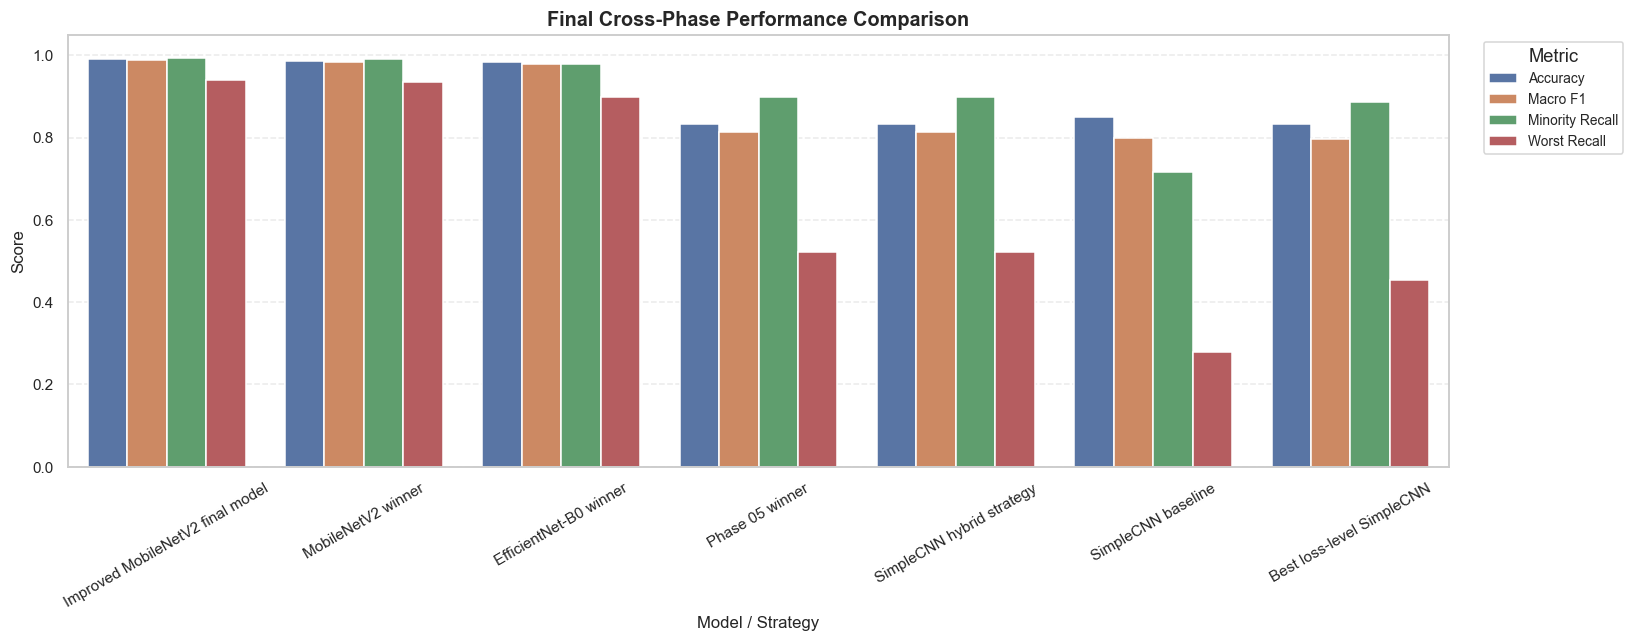

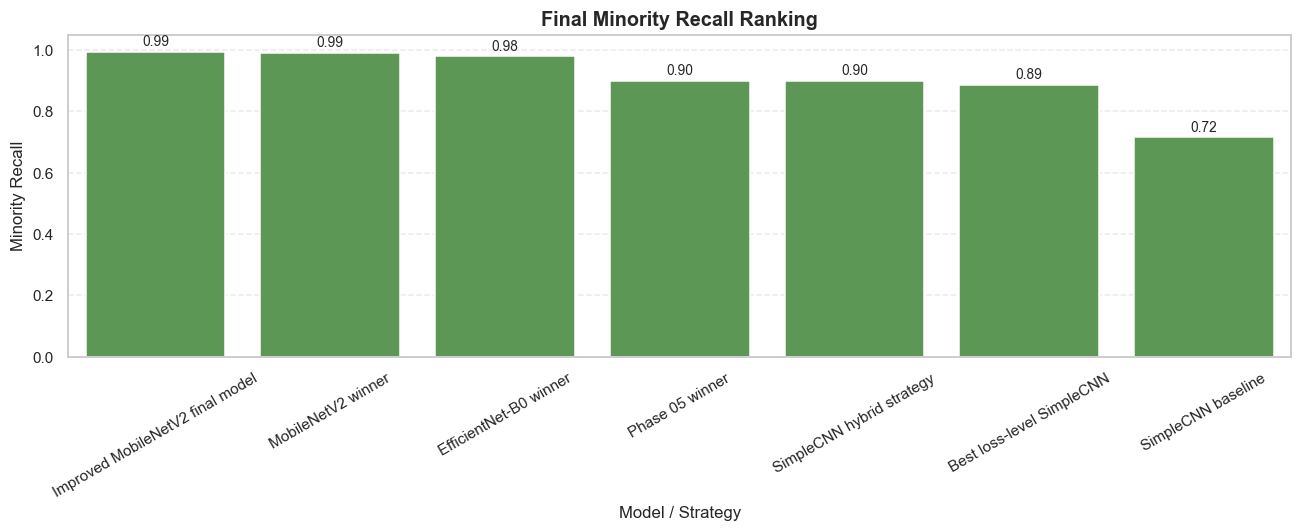

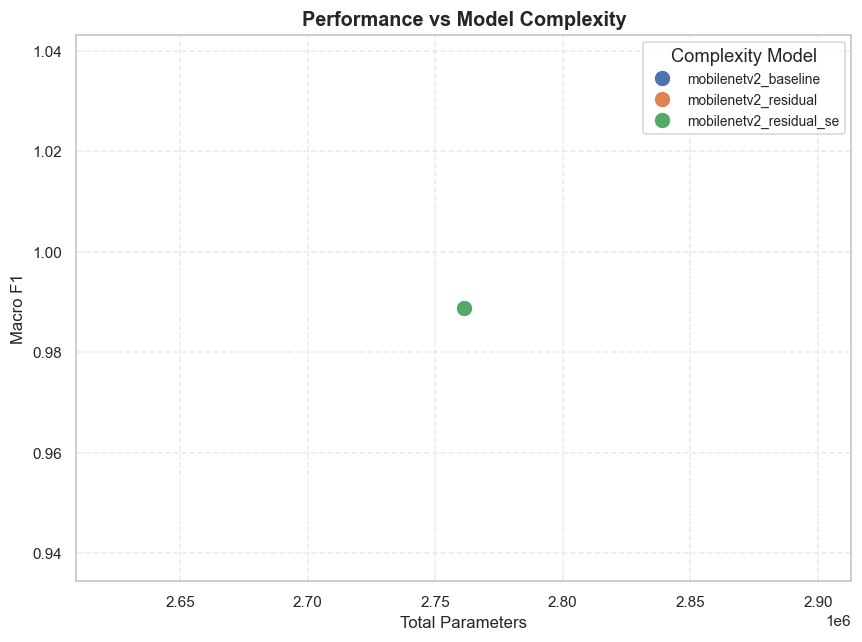

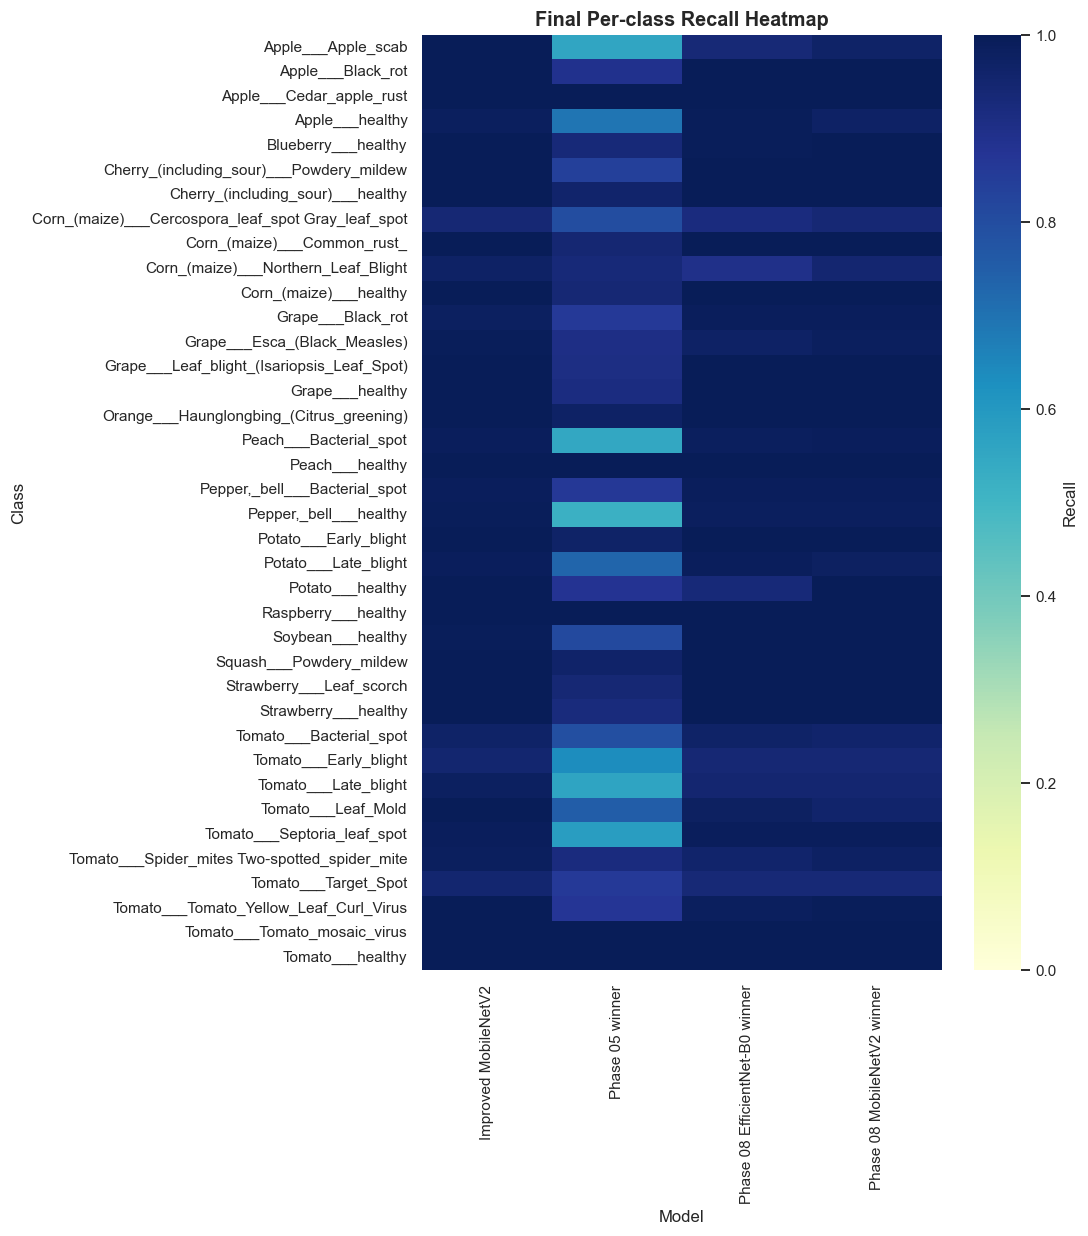

In [11]:
# Final comparison chart.
plot_metrics = ['Accuracy', 'Macro F1', 'Minority Recall', 'Worst Recall']
plot_df = final_comparison_df.melt(
    id_vars=['Phase', 'Model'],
    value_vars=plot_metrics,
    var_name='Metric',
    value_name='Score',
)

plt.figure(figsize=(15, 6))
ax = sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
ax.set_title('Final Cross-Phase Performance Comparison', fontweight='bold')
ax.set_xlabel('Model / Strategy')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PHASE10_FIGURE_DIR / 'final_cross_phase_metric_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Fairness ranking.
plt.figure(figsize=(12, 5))
rank_df = fairness_df.sort_values('Minority Recall', ascending=False)
ax = sns.barplot(data=rank_df, x='Model', y='Minority Recall', color='#54A24B')
ax.set_title('Final Minority Recall Ranking', fontweight='bold')
ax.set_xlabel('Model / Strategy')
ax.set_ylabel('Minority Recall')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', linestyle='--', alpha=0.4)
annotate_bars(ax)
plt.tight_layout()
plt.savefig(PHASE10_FIGURE_DIR / 'final_minority_recall_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

# Performance vs complexity if available.
if not efficiency_df.empty and 'Total Params' in efficiency_df.columns:
    complexity_perf_df = efficiency_df.rename(columns={'Model': 'Complexity Model'}).merge(
        final_comparison_df,
        left_on='Complexity Model',
        right_on='Experiment',
        how='left',
    )
    if complexity_perf_df['Macro F1'].notna().any():
        plt.figure(figsize=(8, 6))
        ax = sns.scatterplot(
            data=complexity_perf_df,
            x='Total Params',
            y='Macro F1',
            hue='Complexity Model',
            s=120,
        )
        ax.set_title('Performance vs Model Complexity', fontweight='bold')
        ax.set_xlabel('Total Parameters')
        ax.set_ylabel('Macro F1')
        ax.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.savefig(PHASE10_FIGURE_DIR / 'performance_vs_complexity.png', dpi=300, bbox_inches='tight')
        plt.show()

# Per-class heatmap for final key models.
heatmap_frames = []
for model_label, path, experiment_filter in per_class_sources:
    df = load_per_class_metrics(path)
    if df.empty or 'Recall' not in df.columns:
        continue
    if experiment_filter is not None and 'Experiment' in df.columns:
        df = df[df['Experiment'] == experiment_filter]
    tmp = df[['Class', 'Recall']].copy()
    tmp['Model'] = model_label
    heatmap_frames.append(tmp)

if heatmap_frames:
    heatmap_df = pd.concat(heatmap_frames, ignore_index=True).pivot(index='Class', columns='Model', values='Recall')
    plt.figure(figsize=(10, max(10, len(heatmap_df) * 0.30)))
    sns.heatmap(heatmap_df, cmap='YlGnBu', vmin=0, vmax=1, cbar_kws={'label': 'Recall'})
    plt.title('Final Per-class Recall Heatmap', fontweight='bold')
    plt.xlabel('Model')
    plt.ylabel('Class')
    plt.tight_layout()
    plt.savefig(PHASE10_FIGURE_DIR / 'final_per_class_recall_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()




# 12. Explainability synthesis

Tổng hợp Grad-CAM/Grad-CAM++ artifacts từ Phase 09 nếu có. Nếu chưa có, ghi nhận là limitation.


In [12]:
gradcam_dir = RESULTS_ROOT / '09_improved_mobilenetv2_architecture_study' / 'phase_09_improved_mobilenetv2' / 'gradcam'
gradcam_files = sorted(gradcam_dir.glob('*.png')) if gradcam_dir.exists() else []

explainability_summary = {
    'Grad-CAM artifact count': len(gradcam_files),
    'Grad-CAM directory': str(gradcam_dir),
    'Interpretation': 'Grad-CAM panels available for qualitative localization analysis.' if gradcam_files else 'No Grad-CAM panels found yet. Run Phase 09 Grad-CAM cell after training final models.'
}

explainability_df = pd.DataFrame([explainability_summary])
explainability_df.to_csv(PHASE10_TABLE_DIR / 'explainability_synthesis.csv', index=False)
display(explainability_df)



,Grad-CAM artifact count,Grad-CAM directory,Interpretation
0,4,/Users/huynh/codes/kpdl/plan/results/09_improv...,Grad-CAM panels available for qualitative loca...


# 13. Core scientific insights

Các insight được tạo dựa trên evidence từ bảng tổng hợp.


In [13]:
insights = []

insights.append('Minority exposure là yếu tố trung tâm trong severe class imbalance. WeightedRandomSampler cải thiện cơ hội xuất hiện của minority samples trong mini-batch, qua đó thường làm tăng Minority Recall và Worst Recall.')
insights.append('Loss-level balancing không nhất thiết vượt sampler-based balancing. Weighted CE, Focal Loss và Class-Balanced Loss thay đổi optimization objective, nhưng có thể gây instability nếu weighting quá mạnh.')
insights.append('Phase 07 kiểm tra hybrid SimpleCNN: kết hợp winner sampler/data-level của Phase 05 với winner loss-level của Phase 06 để đánh giá hiệu ứng bổ trợ.')
insights.append('Phase 08 trực tiếp đáp ứng yêu cầu dùng hai mô hình học sâu hiện đại bằng cách so sánh MobileNetV2 và EfficientNet-B0 trong cùng winner imbalance strategy.')
insights.append('Improved MobileNetV2 chỉ nên được chọn nếu residual/attention enhancement cải thiện Macro F1 hoặc Minority Recall tương xứng với chi phí parameter/inference time.')
insights.append('Accuracy không phải metric đủ tin cậy trong severe imbalance. Macro F1, Minority Recall và Worst Recall phản ánh fairness-aware performance tốt hơn.')

insight_df = pd.DataFrame({'Insight_ID': range(1, len(insights) + 1), 'Scientific Insight': insights})
insight_df.to_csv(PHASE10_TABLE_DIR / 'core_scientific_insights.csv', index=False)
display(insight_df)


,Insight_ID,Scientific Insight
0,1,Minority exposure là yếu tố trung tâm trong se...
1,2,Loss-level balancing không nhất thiết vượt sam...
2,3,Phase 07 kiểm tra hybrid SimpleCNN: kết hợp wi...
3,4,Phase 08 trực tiếp đáp ứng yêu cầu dùng hai mô...
4,5,Improved MobileNetV2 chỉ nên được chọn nếu res...
5,6,Accuracy không phải metric đủ tin cậy trong se...


# 14. Limitations and future work

Phần này viết theo chuẩn research: trung thực, không overclaim.


In [14]:
limitations = [
    'Một số phase có thể chỉ có single-run, nên statistical significance chưa mạnh bằng multi-seed experiments.',
    'Một số phase trước dùng subset để nghiên cứu nhanh; Phase 08/09 dùng full data nhưng cross-phase comparison cần diễn giải cẩn trọng.',
    'PlantVillage là dataset tương đối sạch, có thể không phản ánh đầy đủ điều kiện ảnh ngoài thực địa.',
    'Chưa có cross-dataset validation hoặc external field-image validation.',
    'Hyperparameter search còn giới hạn do computational budget.',
    'Grad-CAM/Grad-CAM++ là explainability định tính, không chứng minh causal reasoning của model.',
    'Chưa so sánh với Vision Transformer hoặc self-supervised pretrained backbones.',
]

future_work = [
    'Chạy multi-seed experiments để báo cáo mean/std và statistical significance mạnh hơn.',
    'Thử cross-dataset validation trên dữ liệu thực địa hoặc dataset bệnh cây khác.',
    'So sánh thêm với Vision Transformer và self-supervised pretrained models.',
    'Tối ưu deployment bằng pruning, quantization hoặc knowledge distillation.',
    'Kết hợp disease localization/segmentation để tăng explainability và robustness.',
    'Đánh giá latency, memory và energy consumption trực tiếp trên mobile/edge devices.',
    'Thiết kế augmentation mạnh hơn nhưng vẫn bảo toàn triệu chứng bệnh.',
]

limitations_df = pd.DataFrame({'Limitation': limitations})
future_work_df = pd.DataFrame({'Future Work': future_work})
limitations_df.to_csv(PHASE10_TABLE_DIR / 'limitations.csv', index=False)
future_work_df.to_csv(PHASE10_TABLE_DIR / 'future_work.csv', index=False)

display(limitations_df)
display(future_work_df)



,Limitation
0,"Một số phase có thể chỉ có single-run, nên sta..."
1,Một số phase trước dùng subset để nghiên cứu n...
2,"PlantVillage là dataset tương đối sạch, có thể..."
3,Chưa có cross-dataset validation hoặc external...
4,Hyperparameter search còn giới hạn do computat...
5,Grad-CAM/Grad-CAM++ là explainability định tín...
6,Chưa so sánh với Vision Transformer hoặc self-...


,Future Work
0,Chạy multi-seed experiments để báo cáo mean/st...
1,Thử cross-dataset validation trên dữ liệu thực...
2,So sánh thêm với Vision Transformer và self-su...
3,"Tối ưu deployment bằng pruning, quantization h..."
4,Kết hợp disease localization/segmentation để t...
5,"Đánh giá latency, memory và energy consumption..."
6,Thiết kế augmentation mạnh hơn nhưng vẫn bảo t...


# 15. Final research discussion and conclusion

Cell này tạo scientific narrative cuối cùng cho thesis/paper.


In [15]:
discussion_text = f"""
FINAL DISCUSSION
================

Dự án PlantVillage Disease Classification được triển khai như một chuỗi nghiên cứu có cấu trúc, bắt đầu từ dữ liệu và SimpleCNN baseline, mở rộng sang sampler-based imbalance handling, loss-level balancing, SimpleCNN hybrid strategy, modern transfer learning và cuối cùng là kiến trúc MobileNetV2 cải tiến. Kết quả tổng hợp cho thấy severe class imbalance không thể được đánh giá chỉ bằng Accuracy. Các metric như Macro F1, Minority Recall và Worst Recall cung cấp góc nhìn công bằng hơn về khả năng nhận diện bệnh hiếm.

Phase 05 cho thấy sampler-based balancing, đặc biệt WeightedRandomSampler kết hợp light augmentation và EarlyStopping theo Validation Macro F1, là một chiến lược hiệu quả để tăng minority exposure. Phase 06 chỉ ra rằng loss-level balancing có giá trị nghiên cứu, nhưng không mặc định vượt sampler-based balancing. Phase 07 kết hợp winner của Phase 05 và Phase 06 trong một SimpleCNN hybrid experiment để kiểm tra liệu sampler/data-level balancing và loss-level balancing có bổ trợ nhau hay không. MobileNetV2/EfficientNet-B0 chỉ bắt đầu từ Phase 08.

Phase 08 là phase huấn luyện chính cho hai mô hình học sâu hiện đại: MobileNetV2 pretrained và EfficientNet-B0 pretrained. Cả hai được đánh giá trên cùng split, cùng augmentation, cùng WeightedRandomSampler và cùng EarlyStopping để so sánh công bằng. Phase 09 tiếp tục kiểm tra liệu residual enhancement và attention mechanism có cải thiện MobileNetV2 baseline hay không, đồng thời xem xét trade-off giữa performance và computational efficiency.

Best overall model theo Macro F1 là `{best_overall_model['Model']}` (`{best_overall_model['Experiment']}`) với Macro F1 = {best_overall_model['Macro F1']:.4f}. Best fairness-aware model theo Minority Recall/Worst Recall là `{best_fairness_model['Model']}` (`{best_fairness_model['Experiment']}`) với Minority Recall = {best_fairness_model['Minority Recall']:.4f}. Các kết quả này nhấn mạnh rằng mô hình cuối không chỉ cần Accuracy cao mà còn phải ổn định trên minority classes.

Nhìn chung, project cho thấy modern pretrained CNN backbones và imbalance-aware training là hai thành phần bổ trợ quan trọng. MobileNetV2/EfficientNet-B0-based pipeline là hướng phù hợp cho yêu cầu đồ án học máy vì vừa có so sánh mô hình học sâu hiện đại, vừa có phân tích lỗi, imbalance và fairness-aware metrics.
""".strip()

conclusion_text = f"""
FINAL CONCLUSION
================

Nghiên cứu này xây dựng một pipeline đầy đủ cho PlantVillage Disease Classification dưới severe class imbalance. Các kết quả cho thấy WeightedRandomSampler và light augmentation cải thiện minority exposure; loss-level balancing cung cấp một hướng tối ưu hóa bổ sung nhưng cần kiểm soát độ ổn định; Phase 07 kiểm tra hybrid SimpleCNN trước khi mở rộng; Phase 08 so sánh trực tiếp MobileNetV2 và EfficientNet-B0 như hai mô hình học sâu hiện đại; và Phase 09 đánh giá khả năng cải tiến MobileNetV2 bằng residual/attention enhancement.

Kết luận cuối cùng là modern pretrained CNN backbone kết hợp imbalance-aware training là final proposed direction phù hợp nhất cho bài toán fairness-aware plant disease classification trong project này.
""".strip()

write_text_report(PHASE10_REPORT_DIR / 'final_discussion.txt', [discussion_text])
write_text_report(PHASE10_REPORT_DIR / 'final_conclusion.txt', [conclusion_text])
print(discussion_text)
print('\n')
print(conclusion_text)


FINAL DISCUSSION

Dự án PlantVillage Disease Classification được triển khai như một chuỗi nghiên cứu có cấu trúc, bắt đầu từ dữ liệu và SimpleCNN baseline, mở rộng sang sampler-based imbalance handling, loss-level balancing, SimpleCNN hybrid strategy, modern transfer learning và cuối cùng là kiến trúc MobileNetV2 cải tiến. Kết quả tổng hợp cho thấy severe class imbalance không thể được đánh giá chỉ bằng Accuracy. Các metric như Macro F1, Minority Recall và Worst Recall cung cấp góc nhìn công bằng hơn về khả năng nhận diện bệnh hiếm.

Phase 05 cho thấy sampler-based balancing, đặc biệt WeightedRandomSampler kết hợp light augmentation và EarlyStopping theo Validation Macro F1, là một chiến lược hiệu quả để tăng minority exposure. Phase 06 chỉ ra rằng loss-level balancing có giá trị nghiên cứu, nhưng không mặc định vượt sampler-based balancing. Phase 07 kết hợp winner của Phase 05 và Phase 06 trong một SimpleCNN hybrid experiment để kiểm tra liệu sampler/data-level balancing và loss-level

# 16. Final report export

Xuất đầy đủ report `.md`, `.txt` và các bảng CSV cuối.


In [16]:
report_sections = []
report_sections.append('# Final Project Report: PlantVillage Disease Classification')
report_sections.append(f'Generated at: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}')
report_sections.append('')
report_sections.append('## 1. Project Overview')
report_sections.append('Dự án nghiên cứu class imbalance handling, transfer learning, lightweight CNN architectures và fairness-aware plant disease classification trên PlantVillage.')
report_sections.append('')
report_sections.append('## 2. Final Cross-Phase Comparison')
report_sections.append(dataframe_to_markdown_safe(final_comparison_df))
report_sections.append('')
report_sections.append('## 3. Final Results Summary')
report_sections.append(dataframe_to_markdown_safe(final_results_summary))
report_sections.append('')
report_sections.append('## 4. Research Question Analysis')
report_sections.append(dataframe_to_markdown_safe(rq_analysis_df))
report_sections.append('')
report_sections.append('## 5. Statistical Analysis')
report_sections.append(dataframe_to_markdown_safe(statistical_analysis_df))
report_sections.append('')
report_sections.append('## 6. Fairness and Imbalance Analysis')
report_sections.append(dataframe_to_markdown_safe(fairness_df))
report_sections.append('')
report_sections.append('## 7. Efficiency Analysis')
report_sections.append(dataframe_to_markdown_safe(efficiency_df) if not efficiency_df.empty else 'Complexity artifacts are not available yet.')
report_sections.append('')
report_sections.append('## 8. Explainability Synthesis')
report_sections.append(dataframe_to_markdown_safe(explainability_df))
report_sections.append('')
report_sections.append('## 9. Hardest-Class / Failure Case Synthesis')
report_sections.append(dataframe_to_markdown_safe(hardest_class_df) if not hardest_class_df.empty else 'No hardest-class artifacts available yet.')
report_sections.append('')
report_sections.append('## 10. Core Scientific Insights')
report_sections.append(dataframe_to_markdown_safe(insight_df))
report_sections.append('')
report_sections.append('## 11. Limitations')
report_sections.append(dataframe_to_markdown_safe(limitations_df))
report_sections.append('')
report_sections.append('## 12. Future Work')
report_sections.append(dataframe_to_markdown_safe(future_work_df))
report_sections.append('')
report_sections.append('## 13. Final Discussion')
report_sections.append(discussion_text)
report_sections.append('')
report_sections.append('## 14. Final Conclusion')
report_sections.append(conclusion_text)

if missing_artifacts:
    missing_df = pd.DataFrame(missing_artifacts).drop_duplicates()
    missing_df.to_csv(PHASE10_TABLE_DIR / 'missing_artifacts.csv', index=False)
    report_sections.append('')
    report_sections.append('## 15. Missing Artifacts')
    report_sections.append(dataframe_to_markdown_safe(missing_df))

write_text_report(PHASE10_REPORT_DIR / 'final_project_report.md', report_sections)
write_text_report(PHASE10_REPORT_DIR / 'final_project_report.txt', report_sections)
write_text_report(PHASE10_DIR / 'final_project_report.md', report_sections)
write_text_report(PHASE10_DIR / 'final_project_report.txt', report_sections)

print(f'Final report saved to: {PHASE10_REPORT_DIR}')
print(f'Final tables saved to: {PHASE10_TABLE_DIR}')
print(f'Final figures saved to: {PHASE10_FIGURE_DIR}')



Final report saved to: /Users/huynh/codes/kpdl/plan/results/10_final_research_synthesis/phase_10_final_research_synthesis/reports
Final tables saved to: /Users/huynh/codes/kpdl/plan/results/10_final_research_synthesis/phase_10_final_research_synthesis/tables
Final figures saved to: /Users/huynh/codes/kpdl/plan/results/10_final_research_synthesis/phase_10_final_research_synthesis/figures
